# Time-to-Depth Conversion of the Seismic Data 

**Author:** Ashraf | **Purpose:** Convert seismic data from time domain to depth domain

---

## 1. Background & Theory

### 1.1 Why Time-to-Depth Conversion?

Seismic data is acquired in the **time domain**: a source generates an acoustic wave, the wave travels into the Earth, reflects off geological interfaces, and returns to the surface. The recorded quantity is signal **amplitude vs. two-way travel time (TWT)** — the round-trip time for the wave to descend and return.

However, geologists and reservoir engineers think in **depth**, not time. A reflector at 1.5 s TWT could be at 1500 m in a fast rock or 900 m in a slow one. To correctly position geological features, we must convert from time to depth using velocity information.

---

### 1.2 The Fundamental Equation

For a seismic wave traveling vertically, the relationship between depth $z$ and one-way travel time $\tau$ is:

$$z = \int_0^{\tau} V(\tau') \, d\tau'$$

Because seismic records **two-way** travel time $t$ (down + up), we divide by 2:

$$\boxed{z(t) = \int_0^{t} \frac{V(t')}{2} \, dt'}$$

Where:
- $z$ = depth (metres)
- $t$ = two-way travel time (seconds)
- $V(t)$ = **interval velocity** at time $t$ (m/s)

---

### 1.3 Discrete Implementation

In practice, seismic data is sampled at a regular time interval $\Delta t$. The integral becomes a cumulative sum:

$$z[i] = z[i-1] + \frac{V[i] \cdot \Delta t}{2}$$

Starting from $z[0] = 0$ (surface), we compute depth sample by sample.

---

### 1.4 Types of Velocity

| Velocity Type | Definition | Use |
|---|---|---|
| **Interval velocity** | Velocity within a specific layer | Direct depth conversion |
| **RMS (Root Mean Square) velocity** | Effective velocity from surface to reflector | NMO correction, velocity analysis |
| **Average velocity** | Simple average $\bar{V} = z/t$ | Approximate depth conversion |

> ⚠️ **Critical:** Use **interval velocity** (or average velocity) — NOT RMS velocity — for time-to-depth conversion. Using RMS velocity directly will give incorrect results.

The Dix formula converts RMS to interval velocity:

$$V_{int}(t_n) = \sqrt{\frac{V_{rms}^2(t_n)\cdot t_n - V_{rms}^2(t_{n-1})\cdot t_{n-1}}{t_n - t_{n-1}}}$$

---

### 1.5 Complete Workflow

```
1. Load seismic data (time domain)         → shape: (n_time_samples, n_traces)
2. Load velocity cube (same time sampling)  → shape: (n_time_samples, n_traces)
3. Validate grids match (same dt, same nt)  → assert shapes match
4. Compute depth axis via cumulative sum    → non-uniform depth values per trace
5. Resample to uniform depth grid           → interpolate each trace
6. Visualize both time and depth sections
```

---

### 1.6 Important Considerations

- **Velocity errors propagate to depth errors.** A 5% velocity error gives ~5% depth error.
- **The velocity and seismic must share the same time sampling** ($\Delta t$ and number of samples).
- After conversion, the depth axis is **non-uniform** (deeper samples are more spread out where velocity is high). Interpolation to a uniform depth grid is needed for display and further processing.
- **Lateral velocity variation** means each trace has a slightly different depth axis — handled trace-by-trace.

---

## 2. Setup — Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
import segyio
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

print('All imports successful.')

All imports successful.


## 3. File Paths

In [4]:

SEISMIC_PATH  = "/home/ashraf/Downloads/ST8511r92.segy"
VELOCITY_PATH = "/media/ashraf/𝓐𝓢𝓗𝓡𝓐𝓕1/Average_Velocity_cube.segy"


## 4. Data Loading

### 4.1 Loading Function

We load SEGY files in **`ignore_geometry`** mode because many 2-D stacks and post-stack volumes lack fully populated 3-D header fields.  
The result is a 2-D array of shape **(n_time_samples, n_traces)**.

In [5]:
def load_segy(filepath, field=segyio.TraceField.CDP):
    """
    Load a SEGY file and return:
        data  – numpy array, shape (n_samples, n_traces), float32
        dt    – sample interval in SECONDS
        trace_id – array of header values for the chosen field (e.g. CDP)
    """
    with segyio.open(filepath, "r", ignore_geometry=True) as f:
        f.mmap()   # memory-map for speed

        # Collect all traces → shape (n_traces, n_samples), then transpose
        data = np.array([t.copy() for t in f.trace[:]]).T   # (n_samples, n_traces)

        # Sample interval: SEGY stores it in microseconds → convert to seconds
        dt_us = segyio.tools.dt(f)
        if dt_us <= 0:
            # Fallback: read directly from the binary header
            dt_us = f.bin[segyio.BinField.Interval]
        dt = dt_us / 1e6   # seconds

        # Trace identifier (CDP, inline, etc.)
        trace_id = np.array([f.header[i][field] for i in range(f.tracecount)])

    return data, dt, trace_id

### 4.2 Load Seismic Data

In [6]:
seismic, dt_seis, cdp_seis = load_segy(SEISMIC_PATH, field=segyio.TraceField.CDP)

n_seis, n_traces = seismic.shape
time_axis = np.arange(n_seis) * dt_seis          # seconds
time_ms   = time_axis * 1000                      # milliseconds (display)

print(f"Seismic — shape : {seismic.shape}")
print(f"          dt    : {dt_seis*1000:.4f} ms")
print(f"          TWT   : 0 – {time_ms[-1]:.1f} ms")
print(f"          CDP   : {cdp_seis.min()} – {cdp_seis.max()}")

Seismic — shape : (227, 112875)
          dt    : 4.0030 ms
          TWT   : 0 – 904.7 ms
          CDP   : 150 – 750


### 4.3 Load Velocity Cube

> **Note:** The velocity SEGY must have the **same number of time samples** and the **same** $\Delta t$ as the seismic.  
> If the velocity cube was built on a different time grid, it must be resampled before use.  
> Here we verify this explicitly.

In [7]:
velocity, dt_vel, cdp_vel = load_segy(VELOCITY_PATH, field=segyio.TraceField.CDP)

n_vel, n_vel_traces = velocity.shape

print(f"Velocity — shape : {velocity.shape}")
print(f"           dt    : {dt_vel*1000:.4f} ms")
print(f"           CDP   : {cdp_vel.min()} – {cdp_vel.max()}")
print(f"           min V : {velocity.min():.1f} m/s")
print(f"           max V : {velocity.max():.1f} m/s")

Velocity — shape : (44, 823680)
           dt    : 4.0000 ms
           CDP   : 1 – 1144
           min V : 1480.0 m/s
           max V : 2260.7 m/s


### 4.4 Grid Matching

The seismic and velocity cubes must share the same time sampling for a direct trace-by-trace conversion.  
If they differ in number of samples or $\Delta t$, we resample the velocity to match the seismic grid.

In [8]:
# ── Check whether grids already match ────────────────────────────────────────
grids_match = (n_seis == n_vel) and np.isclose(dt_seis, dt_vel, rtol=1e-3)

if not grids_match:
    print(f"⚠  Grid mismatch detected!")
    print(f"   Seismic : {n_seis} samples @ {dt_seis*1000:.4f} ms")
    print(f"   Velocity: {n_vel}  samples @ {dt_vel*1000:.4f} ms")
    print("   → Resampling velocity to seismic time grid...")

    # Build time axes for each grid
    time_vel  = np.arange(n_vel)  * dt_vel   # seconds
    time_seis = np.arange(n_seis) * dt_seis  # seconds

    # Interpolate every trace of the velocity cube onto the seismic time axis
    # Use linear interpolation; fill values with edge values (no extrapolation)
    vel_resampled = np.zeros((n_seis, velocity.shape[1]), dtype=np.float32)
    for tr in range(velocity.shape[1]):
        f_interp = interp1d(time_vel, velocity[:, tr],
                            kind='linear', bounds_error=False,
                            fill_value=(velocity[0, tr], velocity[-1, tr]))
        vel_resampled[:, tr] = f_interp(time_seis)

    velocity = vel_resampled
    dt_vel   = dt_seis
    print(f"   ✓ Velocity resampled → shape {velocity.shape}")
else:
    print("✓  Grids match — no resampling needed.")

# ── Now match traces: if velocity has fewer traces, broadcast; else trim ──────
if velocity.shape[1] == 1:
    # Single-trace velocity → broadcast across all seismic traces
    print("   Velocity is 1-D (single trace) — broadcasting to all seismic traces.")
    velocity = np.repeat(velocity, n_traces, axis=1)
elif velocity.shape[1] != n_traces:
    print(f"⚠  Trace count mismatch: seismic={n_traces}, velocity={velocity.shape[1]}")
    print("   → Using nearest-neighbor match on CDP numbers...")
    # Map each seismic CDP to the nearest velocity CDP
    vel_matched = np.zeros((n_seis, n_traces), dtype=np.float32)
    for i, cdp in enumerate(cdp_seis):
        j = np.argmin(np.abs(cdp_vel - cdp))
        vel_matched[:, i] = velocity[:, j]
    velocity = vel_matched
    print(f"   ✓ Velocity matched → shape {velocity.shape}")
else:
    print("✓  Trace counts match.")

print(f"\nFinal velocity array — shape : {velocity.shape}")
print(f"                      min V  : {velocity.min():.1f} m/s")
print(f"                      max V  : {velocity.max():.1f} m/s")

⚠  Grid mismatch detected!
   Seismic : 227 samples @ 4.0030 ms
   Velocity: 44  samples @ 4.0000 ms
   → Resampling velocity to seismic time grid...
   ✓ Velocity resampled → shape (227, 823680)
⚠  Trace count mismatch: seismic=112875, velocity=823680
   → Using nearest-neighbor match on CDP numbers...
   ✓ Velocity matched → shape (227, 112875)

Final velocity array — shape : (227, 112875)
                      min V  : 1480.0 m/s
                      max V  : 2217.6 m/s


### 4.5 Velocity Sanity Check

Geologically reasonable P-wave interval velocities in sedimentary basins are typically in the range **1500 – 6000 m/s**.  
Values outside this range usually indicate a **scaling issue** in the SEGY (e.g., stored as m/s × 100, or as ft/s).

In [9]:
V_MIN_PHYSICAL = 1400.0   # m/s  — slowest sediment (soft marine mud)
V_MAX_PHYSICAL = 7000.0   # m/s  — fast basement / mantle

v_mean = velocity.mean()
v_min  = velocity.min()
v_max  = velocity.max()

print(f"Velocity statistics:")
print(f"  Mean : {v_mean:8.1f} m/s")
print(f"  Min  : {v_min:8.1f} m/s")
print(f"  Max  : {v_max:8.1f} m/s")

# ── Auto-scale if clearly wrong ───────────────────────────────────────────────
if v_max > V_MAX_PHYSICAL and v_max <= V_MAX_PHYSICAL * 100:
    print("\n⚠  Velocities appear to be stored scaled (× 100). Dividing by 100...")
    velocity = velocity / 100.0
    print(f"   After rescale — mean: {velocity.mean():.1f} | min: {velocity.min():.1f} | max: {velocity.max():.1f} m/s")
elif v_min < 0:
    # Absolute value — some software stores with sign convention
    print("\n⚠  Negative velocities detected. Taking absolute value...")
    velocity = np.abs(velocity)
    print(f"   After fix — mean: {velocity.mean():.1f} | min: {velocity.min():.1f} | max: {velocity.max():.1f} m/s")
else:
    print("\n✓  Velocity values are within the physically reasonable range.")

# Clip any remaining outliers to safe bounds
velocity = np.clip(velocity, V_MIN_PHYSICAL, V_MAX_PHYSICAL)

Velocity statistics:
  Mean :   2126.4 m/s
  Min  :   1480.0 m/s
  Max  :   2217.6 m/s

✓  Velocity values are within the physically reasonable range.


## 5. Exploratory Visualisation

Before converting, let's look at what we have.

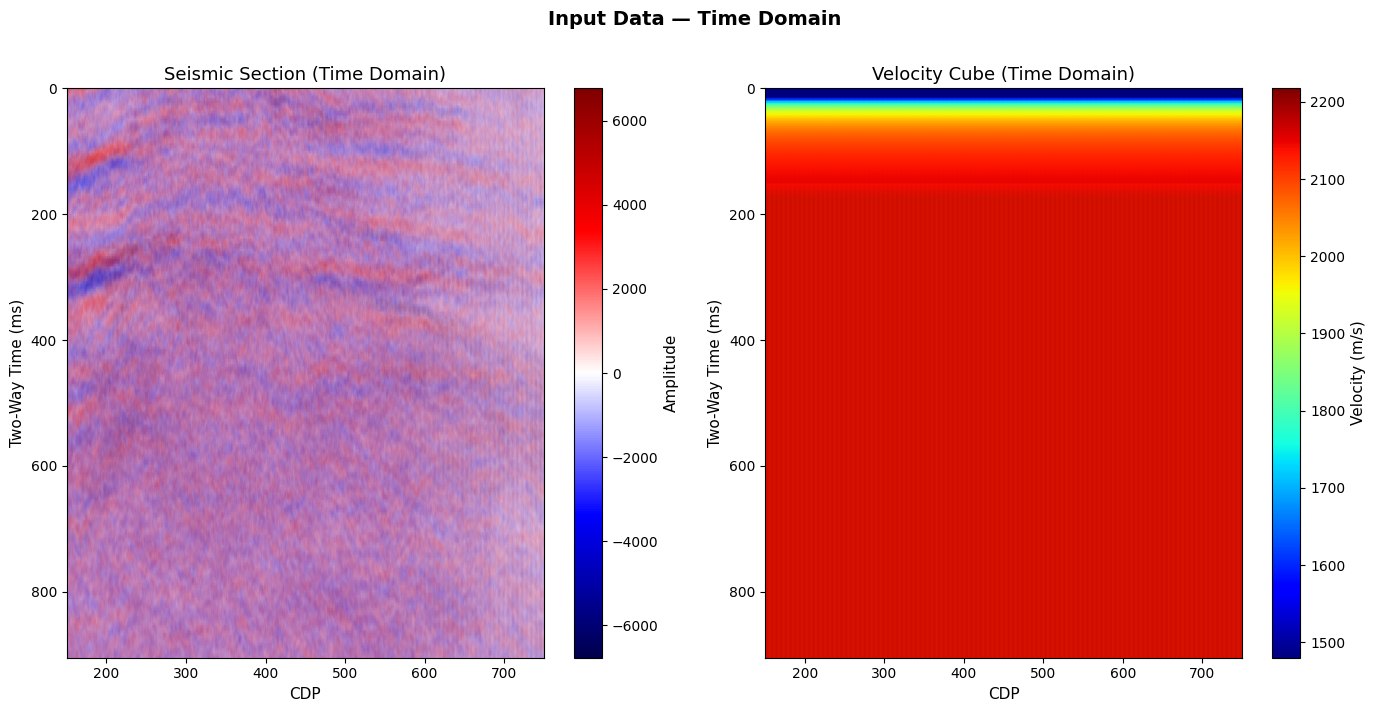

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Seismic section ───────────────────────────────────────────────────────────
clip = np.percentile(np.abs(seismic), 99)
im1 = axes[0].imshow(
    seismic, cmap='seismic', aspect='auto',
    extent=[cdp_seis[0], cdp_seis[-1], time_ms[-1], 0],
    vmin=-clip, vmax=clip
)
axes[0].set_title('Seismic Section (Time Domain)')
axes[0].set_xlabel('CDP')
axes[0].set_ylabel('Two-Way Time (ms)')
plt.colorbar(im1, ax=axes[0], label='Amplitude')

# ── Velocity section ──────────────────────────────────────────────────────────
im2 = axes[1].imshow(
    velocity, cmap='jet', aspect='auto',
    extent=[cdp_seis[0], cdp_seis[-1], time_ms[-1], 0],
    vmin=velocity.min(), vmax=velocity.max()
)
axes[1].set_title('Velocity Cube (Time Domain)')
axes[1].set_xlabel('CDP')
axes[1].set_ylabel('Two-Way Time (ms)')
plt.colorbar(im2, ax=axes[1], label='Velocity (m/s)')

plt.suptitle('Input Data — Time Domain', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Single-Trace Velocity Profile

Inspect the velocity trend on the central trace to confirm it is physically reasonable (increasing with depth).

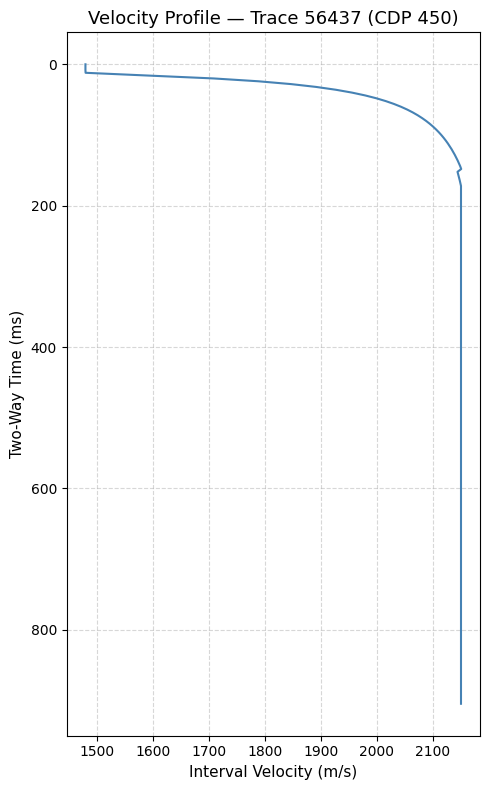

In [10]:
mid_trace = n_traces // 2

fig, ax = plt.subplots(figsize=(5, 8))
ax.plot(velocity[:, mid_trace], time_ms, color='steelblue', linewidth=1.5)
ax.set_xlabel('Interval Velocity (m/s)')
ax.set_ylabel('Two-Way Time (ms)')
ax.set_title(f'Velocity Profile — Trace {mid_trace} (CDP {cdp_seis[mid_trace]})')
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Time-to-Depth Conversion

### 7.1 Theory (Recap)

The conversion is a cumulative numerical integration:

$$z[0] = 0 \qquad z[i] = z[i-1] + \frac{V[i] \cdot \Delta t}{2}$$

This produces a **depth axis** $z[i]$ for each time sample $i$.  
The seismic **amplitude** at time sample $i$, trace $j$ is then placed at depth $z_j[i]$.

Because velocity varies trace-to-trace, each column of the data ends up on a **slightly different, non-uniform depth scale**.  
We therefore:
1. Compute the depth axis per trace.
2. Define a **common uniform depth grid** spanning all traces.
3. **Interpolate** each trace onto this common grid.

### 7.2 Implementation

In [11]:
# ── Step 1: Compute non-uniform depth axis for every trace ────────────────────
#   dz[i, j] = V[i, j] * dt / 2   (depth increment per sample per trace)
#   z[i, j]  = cumulative sum of dz from 0 to i

dz = velocity * dt_seis / 2.0        # shape: (n_samples, n_traces)
z  = np.cumsum(dz, axis=0)           # depth at each time sample, per trace

print("Depth conversion complete.")
print(f"  Depth range (min across all traces)  : 0 – {z.min(axis=1)[-1]:.1f} m")
print(f"  Depth range (max across all traces)  : 0 – {z.max(axis=1)[-1]:.1f} m")
print(f"  Reference depth axis (trace {mid_trace}) : 0 – {z[-1, mid_trace]:.1f} m")

Depth conversion complete.
  Depth range (min across all traces)  : 0 – 941.2 m
  Depth range (max across all traces)  : 0 – 989.3 m
  Reference depth axis (trace 56437) : 0 – 963.9 m


In [12]:
# ── Step 2: Define a common uniform depth grid ────────────────────────────────
#
# We choose:
#   z_min = 0 m (surface)
#   z_max = median of the deepest sample across all traces  (avoids one rogue trace)
#   dz_uniform = chosen to give similar sampling density as the time domain

z_max_all    = np.median(z[-1, :])         # typical maximum depth
dz_uniform   = (z_max_all) / n_seis        # keep same number of depth samples
depth_uniform = np.arange(0, z_max_all, dz_uniform)   # uniform depth axis
n_depth       = len(depth_uniform)

print(f"Uniform depth grid:")
print(f"  Range : 0 – {depth_uniform[-1]:.1f} m")
print(f"  Step  : {dz_uniform:.2f} m")
print(f"  Samples: {n_depth}")

Uniform depth grid:
  Range : 0 – 959.6 m
  Step  : 4.25 m
  Samples: 227


In [13]:
# ── Step 3: Interpolate each trace onto the uniform depth grid ────────────────

seismic_depth = np.zeros((n_depth, n_traces), dtype=np.float32)

for j in range(n_traces):
    # z[:, j] is the depth axis for trace j  (non-uniform, monotonically increasing)
    # seismic[:, j] is the amplitude along that depth axis
    # We interpolate onto depth_uniform
    f_interp = interp1d(
        z[:, j], seismic[:, j],
        kind='linear',
        bounds_error=False,
        fill_value=0.0         # zero amplitude outside the valid range
    )
    seismic_depth[:, j] = f_interp(depth_uniform)

print(f"Depth-domain seismic array — shape: {seismic_depth.shape}")

Depth-domain seismic array — shape: (227, 112875)


## 8. Results & Visualisation

### 8.1 Side-by-Side Comparison

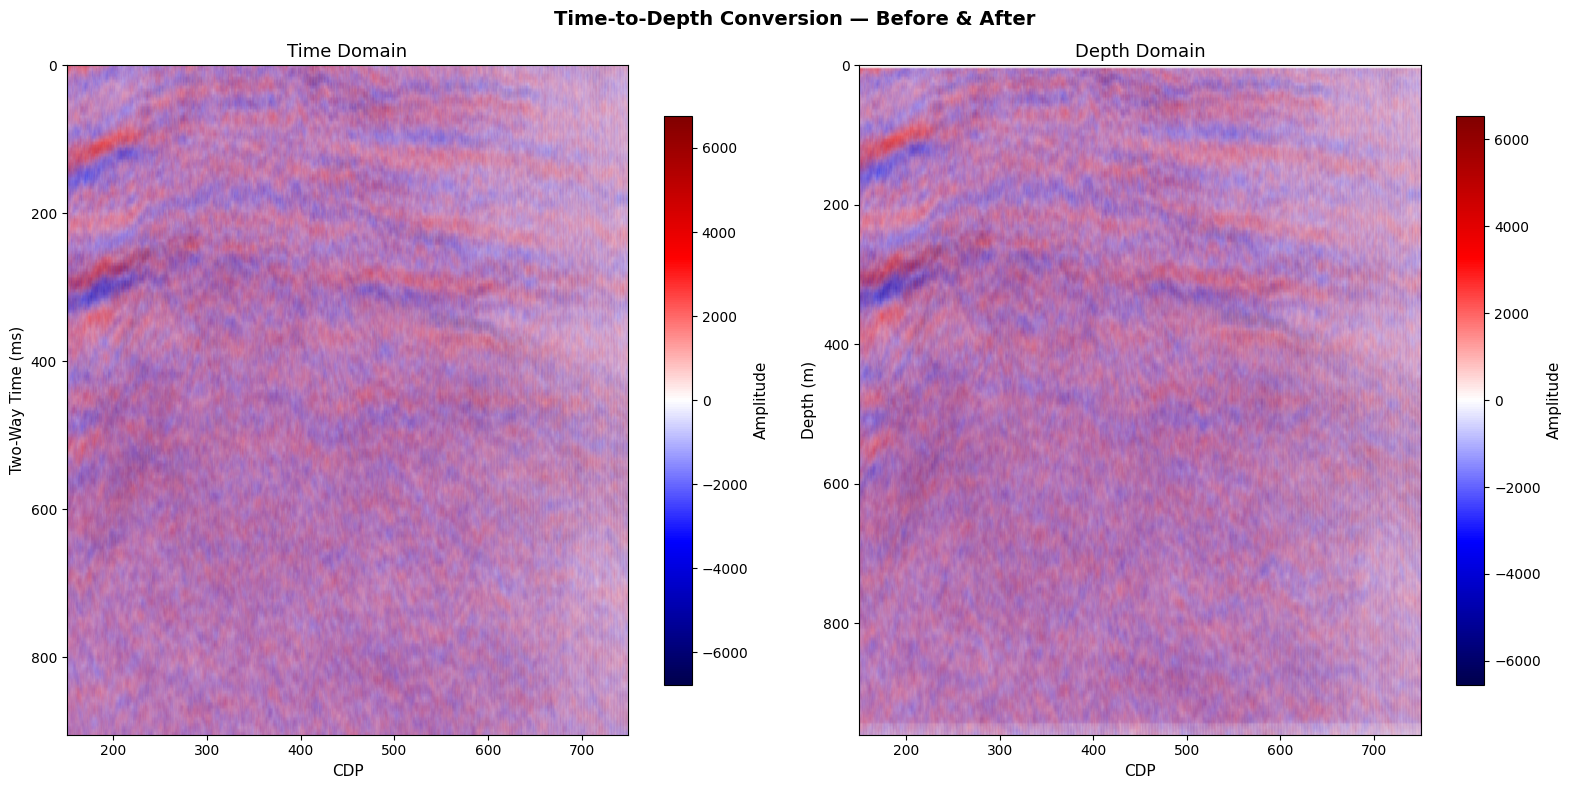

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
clip = np.percentile(np.abs(seismic), 99)

# ── Time domain ───────────────────────────────────────────────────────────────
im1 = axes[0].imshow(
    seismic, cmap='seismic', aspect='auto',
    extent=[cdp_seis[0], cdp_seis[-1], time_ms[-1], 0],
    vmin=-clip, vmax=clip
)
axes[0].set_title('Time Domain', fontsize=13)
axes[0].set_xlabel('CDP')
axes[0].set_ylabel('Two-Way Time (ms)')
plt.colorbar(im1, ax=axes[0], label='Amplitude', shrink=0.85)

# ── Depth domain ──────────────────────────────────────────────────────────────
clip_d = np.percentile(np.abs(seismic_depth), 99)
im2 = axes[1].imshow(
    seismic_depth, cmap='seismic', aspect='auto',
    extent=[cdp_seis[0], cdp_seis[-1], depth_uniform[-1], 0],
    vmin=-clip_d, vmax=clip_d
)
axes[1].set_title('Depth Domain', fontsize=13)
axes[1].set_xlabel('CDP')
axes[1].set_ylabel('Depth (m)')
plt.colorbar(im2, ax=axes[1], label='Amplitude', shrink=0.85)

plt.suptitle('Time-to-Depth Conversion — Before & After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Single-Trace Comparison (Time vs Depth)

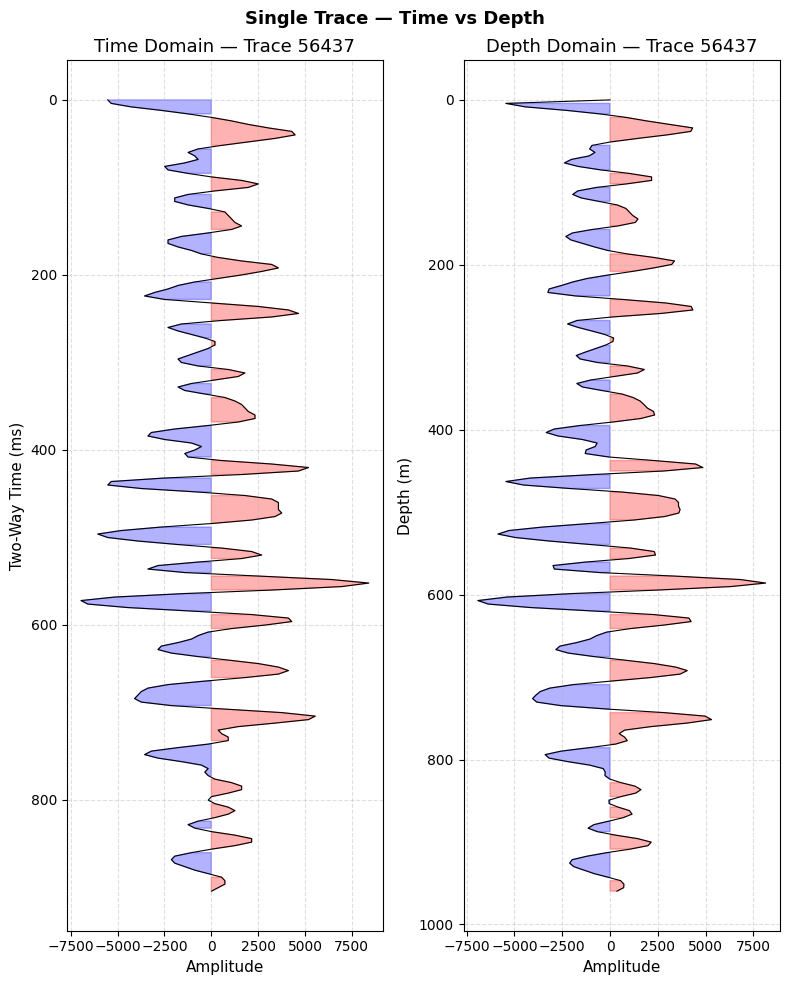

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 10), sharey=False)

trace_idx = mid_trace

# Time-domain trace
axes[0].plot(seismic[:, trace_idx], time_ms, color='black', linewidth=0.8)
axes[0].fill_betweenx(time_ms, seismic[:, trace_idx], 0,
                       where=seismic[:, trace_idx] > 0, color='red',   alpha=0.3)
axes[0].fill_betweenx(time_ms, seismic[:, trace_idx], 0,
                       where=seismic[:, trace_idx] < 0, color='blue',  alpha=0.3)
axes[0].invert_yaxis()
axes[0].set_ylabel('Two-Way Time (ms)')
axes[0].set_xlabel('Amplitude')
axes[0].set_title(f'Time Domain — Trace {trace_idx}')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Depth-domain trace
axes[1].plot(seismic_depth[:, trace_idx], depth_uniform, color='black', linewidth=0.8)
axes[1].fill_betweenx(depth_uniform, seismic_depth[:, trace_idx], 0,
                       where=seismic_depth[:, trace_idx] > 0, color='red',  alpha=0.3)
axes[1].fill_betweenx(depth_uniform, seismic_depth[:, trace_idx], 0,
                       where=seismic_depth[:, trace_idx] < 0, color='blue', alpha=0.3)
axes[1].invert_yaxis()
axes[1].set_ylabel('Depth (m)')
axes[1].set_xlabel('Amplitude')
axes[1].set_title(f'Depth Domain — Trace {trace_idx}')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Single Trace — Time vs Depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Time–Depth Relationship

The plot below shows how the time-to-depth mapping varies across traces.  
A wider spread at a given time indicates strong lateral velocity variation.

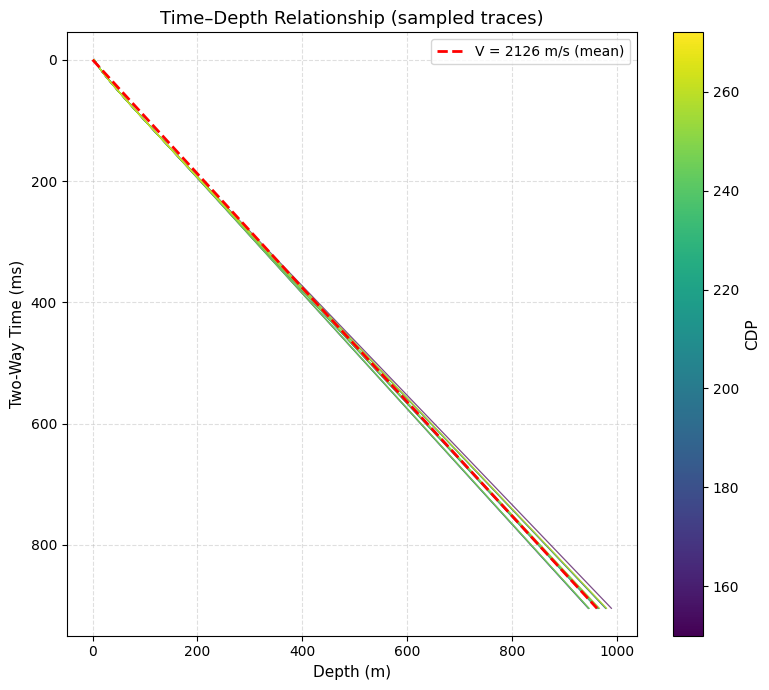

In [16]:
# Use a subset of traces for clarity
n_plot = min(20, n_traces)
step   = n_traces // n_plot
selected = np.arange(0, n_traces, step)[:n_plot]

fig, ax = plt.subplots(figsize=(8, 7))

cmap = plt.cm.viridis
for k, j in enumerate(selected):
    color = cmap(k / n_plot)
    ax.plot(z[:, j], time_ms, color=color, linewidth=0.9, alpha=0.7)

# Reference: constant-velocity line at mean velocity
v_avg = velocity.mean()
z_ref = time_axis / 2 * v_avg
ax.plot(z_ref, time_ms, 'r--', linewidth=2, label=f'V = {v_avg:.0f} m/s (mean)')

ax.set_xlabel('Depth (m)')
ax.set_ylabel('Two-Way Time (ms)')
ax.set_title('Time–Depth Relationship (sampled traces)')
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

sm = plt.cm.ScalarMappable(cmap=cmap,
                             norm=plt.Normalize(cdp_seis[selected[0]],
                                                 cdp_seis[selected[-1]]))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='CDP')
plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [17]:
print("═" * 52)
print("  TIME-TO-DEPTH CONVERSION — SUMMARY")
print("═" * 52)
print(f"  Input  (time domain)  : {n_seis} samples × {n_traces} traces")
print(f"  Sample interval       : {dt_seis*1000:.4f} ms")
print(f"  Max two-way time      : {time_ms[-1]:.1f} ms")
print("─" * 52)
print(f"  Mean interval velocity: {velocity.mean():.1f} m/s")
print(f"  Velocity range        : {velocity.min():.1f} – {velocity.max():.1f} m/s")
print("─" * 52)
print(f"  Output (depth domain) : {n_depth} samples × {n_traces} traces")
print(f"  Depth sample interval : {dz_uniform:.2f} m")
print(f"  Max depth             : {depth_uniform[-1]:.1f} m")
print("═" * 52)

════════════════════════════════════════════════════
  TIME-TO-DEPTH CONVERSION — SUMMARY
════════════════════════════════════════════════════
  Input  (time domain)  : 227 samples × 112875 traces
  Sample interval       : 4.0030 ms
  Max two-way time      : 904.7 ms
────────────────────────────────────────────────────
  Mean interval velocity: 2126.4 m/s
  Velocity range        : 1480.0 – 2217.6 m/s
────────────────────────────────────────────────────
  Output (depth domain) : 227 samples × 112875 traces
  Depth sample interval : 4.25 m
  Max depth             : 959.6 m
════════════════════════════════════════════════════


## 10. Notes & Potential Improvements

1. **Dix conversion:** If only RMS velocities are available, apply the Dix formula (Section 1.4) to obtain interval velocities before running this notebook.

2. **Anti-alias filtering:** When the depth sampling step is larger than the original time-domain equivalent, aliasing can occur. A low-pass filter before interpolation can mitigate this.

3. **Datum correction / static shifts:** If there is a non-zero recording delay (`DelayRecordingTime` in the SEGY header), the time axis should be offset accordingly before conversion.

4. **3-D datasets:** For a 3-D volume, apply the same trace-by-trace procedure. Memory-efficient chunked processing is recommended for large volumes.

5. **Export to SEGY:** Use `segyio.tools.from_array` (or write trace by trace) to save the depth-domain result as a new SEGY file.